<div style="padding:34px 36px; border-radius:18px; background:linear-gradient(135deg,#123A63 0%,#176B87 58%,#1FA187 100%); color:white; margin-bottom:22px; box-shadow:0 8px 24px rgba(18,58,99,.18);">
  <div style="font-size:13px; letter-spacing:2px; font-weight:700; opacity:.88;">CUADERNO 2 · APRENDIZAJE PROFUNDO</div>
  <h1 style="margin:10px 0 8px 0; font-size:36px; color:white;">Entrenamiento y evaluación de instrumentos quirúrgicos</h1>
  <p style="font-size:18px; margin:0; opacity:.94;">Clasificación multilabel con MobileNetV2</p>
  <div style="margin-top:22px; font-size:15px;"><b>Estudiantes:</b> Madeleine Arévalo, Tatiana Aucapiña y Esteban Tuquiñagui &nbsp;&nbsp;|&nbsp;&nbsp; <b>Año:</b> 2026</div>
</div>

### Descripción general

Este cuaderno documenta el proceso completo de entrenamiento de un sistema inteligente para el reconocimiento de instrumentos quirúrgicos. Se desarrollan dos enfoques complementarios:

| Enfoque | Arquitectura | Resultado esperado |
|---|---|---|
| Clasificación multilabel | MobileNetV2 | Determinar qué instrumentos están presentes en una imagen |

**Clases analizadas:** Bisturí n.º 4, Pinza de disección recta, Tijera Mayo recta y Tijera Mayo curva.

> **Recomendación de ejecución:** ejecutar las celdas de forma secuencial para conservar las variables, rutas y modelos generados en cada etapa.

### Índice

1. [Preparación de datos](#1-preparación-de-datos)
2. [Clasificación multilabel con MobileNetV2](#2-clasificación-multilabel-con-mobilenetv2)
3. [Evaluación del clasificador](#3-evaluación-del-clasificador)
5. [Resumen del cuaderno](#5-resumen-del-cuaderno)

---

## 1. Preparación de datos

### 1.1 Reconstrucción de los conjuntos de entrenamiento, validación y prueba

Esta etapa descarga o recupera el conjunto de datos, comprueba su estructura, interpreta las etiquetas y reconstruye los `DataFrame` requeridos para el entrenamiento.

In [ ]:
# ============================================================
# CELDA 1: RECONSTRUIR DATAFRAMES PARA EL ENTRENAMIENTO
# ============================================================

from pathlib import Path
import random

import kagglehub
import numpy as np
import pandas as pd

from PIL import Image
from sklearn.model_selection import train_test_split



# 1. Configuración reproducible

SEED = 42

random.seed(SEED)
np.random.seed(SEED)



# 2. Descargar o recuperar el dataset


KAGGLE_PATH = Path(
    kagglehub.dataset_download(
        "dilavado/labeled-surgical-tools"
    )
)

print("Ruta descargada:")
print(KAGGLE_PATH)


# 3. Definir las rutas internas del dataset

DATASET_DIR = (
    KAGGLE_PATH
    / "Surgical-Dataset"
)

IMAGE_DIR = (
    DATASET_DIR
    / "Images"
    / "All"
    / "images"
)

LABEL_DIR = (
    DATASET_DIR
    / "Labels"
    / "label object names"
)

TRAIN_LIST_PATH = (
    DATASET_DIR
    / "Test-Train Groups"
    / "train-obj_detector.txt"
)

TEST_LIST_PATH = (
    DATASET_DIR
    / "Test-Train Groups"
    / "test-obj_detector.txt"
)



# 4. Comprobar que las carpetas existan

rutas_requeridas = {
    "Imágenes": IMAGE_DIR,
    "Etiquetas": LABEL_DIR,
    "Lista de entrenamiento": TRAIN_LIST_PATH,
    "Lista de prueba": TEST_LIST_PATH
}

for nombre, ruta in rutas_requeridas.items():

    print(
        f"{nombre}: {ruta.exists()} → {ruta}"
    )

    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró la ruta de {nombre}: {ruta}"
        )


# 5. Definir las cuatro clases

CLASS_NAMES = [
    "Bisturí n.º 4",
    "Pinza de disección recta",
    "Tijera Mayo recta",
    "Tijera Mayo curva"
]

NUM_CLASSES = len(CLASS_NAMES)

LABEL_COLUMNS = [
    "y0",
    "y1",
    "y2",
    "y3"
]


# 6. Función para leer una etiqueta YOLO


def leer_etiqueta_yolo(label_path):

    vector = np.zeros(
        NUM_CLASSES,
        dtype=np.int32
    )

    cantidad_objetos = 0
    clases_encontradas = []

    with open(
        label_path,
        mode="r",
        encoding="utf-8"
    ) as archivo:

        for numero_linea, linea in enumerate(
            archivo,
            start=1
        ):

            linea = linea.strip()

            if not linea:
                continue

            elementos = linea.split()

            if len(elementos) < 5:
                raise ValueError(
                    f"Etiqueta YOLO incorrecta en "
                    f"{label_path.name}, línea {numero_linea}"
                )

            clase = int(
                float(elementos[0])
            )

            if clase < 0 or clase >= NUM_CLASSES:
                raise ValueError(
                    f"Clase inválida {clase} "
                    f"en {label_path.name}"
                )

            vector[clase] = 1
            cantidad_objetos += 1
            clases_encontradas.append(clase)

    return (
        vector,
        cantidad_objetos,
        clases_encontradas
    )


# 7. Buscar todas las imágenes originales

EXTENSIONES = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}

images = sorted(
    archivo
    for archivo in IMAGE_DIR.iterdir()
    if archivo.is_file()
    and archivo.suffix.lower() in EXTENSIONES
)

print(
    "\nCantidad de imágenes encontradas:",
    len(images)
)


# 8. Construir el DataFrame general

registros = []
errores = []

for posicion, image_path in enumerate(
    images,
    start=1
):

    label_path = (
        LABEL_DIR
        / f"{image_path.stem}.txt"
    )

    try:

        if not label_path.exists():

            raise FileNotFoundError(
                f"No existe {label_path.name}"
            )

        vector, cantidad_objetos, clases = (
            leer_etiqueta_yolo(label_path)
        )

        with Image.open(image_path) as imagen:

            width, height = imagen.size
            image_mode = imagen.mode

        registro = {
            "path": str(image_path),
            "file": image_path.name,
            "label_path": str(label_path),
            "width": width,
            "height": height,
            "channels_mode": image_mode,
            "object_count": cantidad_objetos,
            "label_count": int(vector.sum()),
            "class_ids": ",".join(
                map(
                    str,
                    sorted(set(clases))
                )
            )
        }

        for indice in range(NUM_CLASSES):

            registro[
                LABEL_COLUMNS[indice]
            ] = int(vector[indice])

        registros.append(registro)

    except Exception as error:

        errores.append({
            "imagen": image_path.name,
            "error": str(error)
        })

    if posicion % 500 == 0:

        print(
            f"Procesadas {posicion} "
            f"de {len(images)} imágenes"
        )


dataset_df = pd.DataFrame(
    registros
)

print(
    "\nImágenes procesadas correctamente:",
    len(dataset_df)
)

print(
    "Errores encontrados:",
    len(errores)
)


# 9. Leer las listas oficiales train y test

def leer_lista_oficial(ruta_txt):

    nombres = []

    with open(
        ruta_txt,
        mode="r",
        encoding="utf-8"
    ) as archivo:

        for linea in archivo:

            linea = linea.strip()

            if not linea:
                continue

            nombre = Path(
                linea.replace("\\", "/")
            ).name

            nombres.append(nombre)

    return nombres


train_files = leer_lista_oficial(
    TRAIN_LIST_PATH
)

test_files = leer_lista_oficial(
    TEST_LIST_PATH
)

train_set = set(train_files)
test_set = set(test_files)


# 10. Asignar la división oficial

dataset_df["split_original"] = np.select(
    [
        dataset_df["file"].isin(train_set),
        dataset_df["file"].isin(test_set)
    ],
    [
        "train",
        "test"
    ],
    default="excluded"
)


train_original_df = dataset_df[
    dataset_df["split_original"] == "train"
].copy().reset_index(drop=True)

test_df = dataset_df[
    dataset_df["split_original"] == "test"
].copy().reset_index(drop=True)


# 11. Crear la validación estratificada

train_original_df[
    "label_combination"
] = (
    train_original_df[
        LABEL_COLUMNS
    ]
    .astype(str)
    .agg("".join, axis=1)
)


frecuencia_combinaciones = (
    train_original_df[
        "label_combination"
    ]
    .value_counts()
)


combinaciones_raras = (
    frecuencia_combinaciones[
        frecuencia_combinaciones < 2
    ]
    .index
    .tolist()
)


rare_df = train_original_df[
    train_original_df[
        "label_combination"
    ].isin(combinaciones_raras)
].copy()


common_df = train_original_df[
    ~train_original_df[
        "label_combination"
    ].isin(combinaciones_raras)
].copy()


common_train_df, val_df = train_test_split(
    common_df,
    test_size=293,
    random_state=SEED,
    shuffle=True,
    stratify=common_df[
        "label_combination"
    ]
)


train_df = pd.concat(
    [
        common_train_df,
        rare_df
    ],
    ignore_index=True
)


train_df = train_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


train_df = train_df.drop(
    columns=["label_combination"],
    errors="ignore"
)

val_df = val_df.drop(
    columns=["label_combination"],
    errors="ignore"
)


train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"


# 12. Comprobación final

print("\n" + "=" * 70)
print("DATOS PREPARADOS PARA EL ENTRENAMIENTO")
print("=" * 70)

print(
    "Entrenamiento:",
    len(train_df)
)

print(
    "Validación:",
    len(val_df)
)

print(
    "Prueba:",
    len(test_df)
)

print(
    "Número de clases:",
    NUM_CLASSES
)

print(
    "Columnas de etiquetas:",
    LABEL_COLUMNS
)

print("\nClases:")

for indice, clase in enumerate(
    CLASS_NAMES
):

    print(
        f"{indice}: {clase}"
    )


print("\nFrecuencia de etiquetas:")

frecuencias = pd.DataFrame(
    {
        "Entrenamiento": train_df[
            LABEL_COLUMNS
        ].sum().values,

        "Validación": val_df[
            LABEL_COLUMNS
        ].sum().values,

        "Prueba": test_df[
            LABEL_COLUMNS
        ].sum().values
    },
    index=CLASS_NAMES
)

display(frecuencias)


print(
    "\n train_df, val_df y test_df "
    "se crearon correctamente."
)

Using Colab cache for faster access to the 'labeled-surgical-tools' dataset.
Ruta descargada:
/kaggle/input/labeled-surgical-tools
Imágenes: True → /kaggle/input/labeled-surgical-tools/Surgical-Dataset/Images/All/images
Etiquetas: True → /kaggle/input/labeled-surgical-tools/Surgical-Dataset/Labels/label object names
Lista de entrenamiento: True → /kaggle/input/labeled-surgical-tools/Surgical-Dataset/Test-Train Groups/train-obj_detector.txt
Lista de prueba: True → /kaggle/input/labeled-surgical-tools/Surgical-Dataset/Test-Train Groups/test-obj_detector.txt

Cantidad de imágenes encontradas: 3009
Procesadas 500 de 3009 imágenes
Procesadas 1000 de 3009 imágenes
Procesadas 1500 de 3009 imágenes
Procesadas 2000 de 3009 imágenes
Procesadas 2500 de 3009 imágenes
Procesadas 3000 de 3009 imágenes

Imágenes procesadas correctamente: 3009
Errores encontrados: 0

DATOS PREPARADOS PARA EL ENTRENAMIENTO
Entrenamiento: 1541
Validación: 293
Prueba: 786
Número de clases: 4
Columnas de etiquetas: ['y0',

,Entrenamiento,Validación,Prueba
Bisturí n.º 4,536,101,273
Pinza de disección recta,535,102,273
Tijera Mayo recta,535,102,272
Tijera Mayo curva,535,102,274



 train_df, val_df y test_df se crearon correctamente.


### 1.2 Creación de los conjuntos de datos para TensorFlow

Las rutas y etiquetas se convierten en objetos `tf.data.Dataset`. Aquí se realiza la lectura, decodificación, redimensionamiento y preparación de lotes para entrenamiento, validación y prueba.

> **Control visual:** al finalizar esta etapa se comprueban las dimensiones de los lotes y la correspondencia entre imágenes y etiquetas.

In [ ]:

import tensorflow as tf
import numpy as np


# 1. Configuración

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE


# 2. Función para leer y preparar una imagen

def cargar_imagen(ruta_imagen, etiquetas):

    # Leer el archivo de imagen
    imagen = tf.io.read_file(ruta_imagen)

    # Decodificar JPG, PNG u otro formato compatible
    imagen = tf.io.decode_image(
        imagen,
        channels=3,
        expand_animations=False
    )

    # Definir explícitamente que la imagen tiene tres canales
    imagen.set_shape([None, None, 3])

    # Redimensionar la imagen
    imagen = tf.image.resize(
        imagen,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    # Convertir la imagen a float32
    imagen = tf.cast(
        imagen,
        tf.float32
    )

    # Convertir las etiquetas a float32
    etiquetas = tf.cast(
        etiquetas,
        tf.float32
    )

    return imagen, etiquetas


# 3. Función para crear un dataset

def crear_dataset(
    dataframe,
    entrenamiento=False
):

    # Obtener las rutas de las imágenes
    rutas = dataframe[
        "path"
    ].astype(str).to_numpy()

    # Obtener las cuatro etiquetas multilabel
    etiquetas = dataframe[
        LABEL_COLUMNS
    ].astype(
        "float32"
    ).to_numpy()

    # Crear el dataset
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            rutas,
            etiquetas
        )
    )

    # Mezclar únicamente las imágenes de entrenamiento
    if entrenamiento:

        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    # Leer y transformar las imágenes
    dataset = dataset.map(
        cargar_imagen,
        num_parallel_calls=AUTOTUNE
    )

    # Organizar las imágenes en lotes
    dataset = dataset.batch(
        BATCH_SIZE
    )

    # Preparar el siguiente lote mientras se entrena
    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


# 4. Crear entrenamiento, validación y prueba

train_ds = crear_dataset(
    train_df,
    entrenamiento=True
)

val_ds = crear_dataset(
    val_df,
    entrenamiento=False
)

test_ds = crear_dataset(
    test_df,
    entrenamiento=False
)


# 5. Comprobar un lote

for imagenes_batch, etiquetas_batch in train_ds.take(1):

    print("=" * 70)
    print("COMPROBACIÓN DEL DATASET")
    print("=" * 70)

    print(
        "Forma del lote de imágenes:",
        imagenes_batch.shape
    )

    print(
        "Forma del lote de etiquetas:",
        etiquetas_batch.shape
    )

    print(
        "Tipo de dato de imágenes:",
        imagenes_batch.dtype
    )

    print(
        "Tipo de dato de etiquetas:",
        etiquetas_batch.dtype
    )

    print(
        "\nPrimera etiqueta multilabel:",
        etiquetas_batch[0].numpy()
    )

    print(
        "Valor mínimo de píxel:",
        float(
            tf.reduce_min(
                imagenes_batch
            ).numpy()
        )
    )

    print(
        "Valor máximo de píxel:",
        float(
            tf.reduce_max(
                imagenes_batch
            ).numpy()
        )
    )


print("\n✅ Datasets creados correctamente.")

COMPROBACIÓN DEL DATASET
Forma del lote de imágenes: (32, 224, 224, 3)
Forma del lote de etiquetas: (32, 4)
Tipo de dato de imágenes: <dtype: 'float32'>
Tipo de dato de etiquetas: <dtype: 'float32'>

Primera etiqueta multilabel: [1. 0. 0. 1.]
Valor mínimo de píxel: 11.010156631469727
Valor máximo de píxel: 255.0

✅ Datasets creados correctamente.


---

## 2. Clasificación multilabel con MobileNetV2

### 2.1 Construcción del modelo

Se utiliza transferencia de aprendizaje con MobileNetV2 como extractor de características. La capa de salida contiene cuatro neuronas con activación sigmoide, una por cada instrumento.

| Componente | Función |
|---|---|
| Aumento de datos | Mejora la variabilidad de las imágenes durante el entrenamiento |
| MobileNetV2 | Extrae características visuales de alto nivel |
| Capa sigmoide | Calcula probabilidades independientes para las cuatro clases |

In [ ]:

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


# 1. Número de clases

NUM_CLASSES = len(CLASS_NAMES)

print("Número de clases:", NUM_CLASSES)


# 2. Aumento de datos


data_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            mode="horizontal_and_vertical"
        ),

        layers.RandomRotation(
            factor=0.12,
            fill_mode="reflect"
        ),

        layers.RandomTranslation(
            height_factor=0.08,
            width_factor=0.08,
            fill_mode="reflect"
        ),

        layers.RandomZoom(
            height_factor=0.15,
            width_factor=0.15,
            fill_mode="reflect"
        ),

        layers.RandomContrast(
            factor=0.20
        ),

        layers.RandomBrightness(
            factor=0.15,
            value_range=(0, 255)
        ),

        layers.GaussianNoise(
            stddev=3.0
        )
    ],
    name="aumento_datos"
)


# 3. Cargar MobileNetV2 preentrenada

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(
        IMG_HEIGHT,
        IMG_WIDTH,
        3
    ),

    include_top=False,

    weights="imagenet"
)


# 4. Congelar MobileNetV2

base_model.trainable = False


# 5. Entrada del modelo

inputs = keras.Input(
    shape=(
        IMG_HEIGHT,
        IMG_WIDTH,
        3
    ),
    name="imagen_entrada"
)



# 6. Aplicar aumento de datos

x = data_augmentation(
    inputs
)


# 7. Normalizar para MobileNetV2
#
# MobileNetV2 necesita valores entre -1 y 1.
# Las imágenes actualmente están entre 0 y 255.

x = layers.Rescaling(
    scale=1.0 / 127.5,
    offset=-1
)(
    x
)


# 8. Extraer características visuales

x = base_model(
    x,
    training=False
)


# 9. Reducir los mapas de características

x = layers.GlobalAveragePooling2D(
    name="promedio_global"
)(
    x
)


# 10. Regularización


x = layers.Dropout(
    rate=0.35,
    name="dropout_1"
)(
    x
)


# 11. Capa densa

x = layers.Dense(
    units=128,
    activation="relu",
    name="capa_densa"
)(
    x
)



# 12. Normalización

x = layers.BatchNormalization(
    name="normalizacion"
)(
    x
)


# 13. Segunda capa de regularización

x = layers.Dropout(
    rate=0.25,
    name="dropout_2"
)(
    x
)


# 14. Salida multilabel
#
# Se utiliza sigmoid porque una misma imagen puede contener
# varios instrumentos al mismo tiempo.

outputs = layers.Dense(
    units=NUM_CLASSES,
    activation="sigmoid",
    name="probabilidades"
)(
    x
)


# 15. Construir el modelo

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="clasificador_instrumentos_quirurgicos"
)


# 16. Compilar el modelo

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=5e-6,
        weight_decay=1e-5
    ),

    loss=keras.losses.BinaryCrossentropy(
        label_smoothing=0.02
    ),

    metrics=[
        keras.metrics.BinaryAccuracy(
            name="binary_accuracy",
            threshold=0.5
        ),
        keras.metrics.Precision(
            name="precision",
            thresholds=0.5
        ),
        keras.metrics.Recall(
            name="recall",
            thresholds=0.5
        ),
        keras.metrics.AUC(
            name="auc",
            multi_label=True,
            num_labels=NUM_CLASSES
        )
    ]
)


# 17. Mostrar estructura del modelo

model.summary()


print("\n" + "=" * 70)
print("MODELO CREADO CORRECTAMENTE")
print("=" * 70)

print(
    "Modelo base entrenable:",
    base_model.trainable
)

print(
    "Número de salidas:",
    model.output_shape[-1]
)

print(
    "Función de pérdida:",
    model.loss
)

print(
    "\n✅ El modelo está listo para iniciar el entrenamiento."
)

Número de clases: 4
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "clasificador_instrumentos_quirurgicos"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen_entrada (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aumento_datos (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ promedio_global                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_densa (Dense)              │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalizacion                   │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probabilidades (Dense)          │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,980 (9.24 MB)

 Trainable params: 164,740 (643.52 KB)

 Non-trainable params: 2,258,240 (8.61 MB)


MODELO CREADO CORRECTAMENTE
Modelo base entrenable: False
Número de salidas: 4
Función de pérdida: binary_crossentropy

✅ El modelo está listo para iniciar el entrenamiento.


### 2.2 Entrenamiento inicial

Se configura la primera fase de entrenamiento con la base MobileNetV2 congelada. Los *callbacks* permiten conservar el mejor modelo, detener el proceso si deja de mejorar y ajustar la tasa de aprendizaje.

> **Criterio principal:** la selección del mejor modelo se realiza utilizando el desempeño sobre el conjunto de validación.

In [ ]:

import os
import tensorflow as tf

from tensorflow import keras


# 1. Crear carpeta para guardar los resultados

CARPETA_MODELOS = "/content/modelos_instrumentos"

os.makedirs(
    CARPETA_MODELOS,
    exist_ok=True
)


# 2. Ruta donde se guardará el mejor modelo

RUTA_MEJOR_MODELO = os.path.join(
    CARPETA_MODELOS,
    "mejor_modelo_instrumentos.keras"
)


# 3. Callback para guardar únicamente el mejor modelo

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=RUTA_MEJOR_MODELO,

    # Se observa la pérdida de validación
    monitor="val_loss",

    # Se busca el valor más pequeño
    mode="min",

    # Guardar únicamente cuando mejore
    save_best_only=True,

    # Guardar el modelo completo
    save_weights_only=False,

    verbose=1
)


# 4. Detener si el modelo deja de mejorar


early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",

    mode="min",

    # Esperar 6 épocas antes de detener
    patience=8,

    # Recuperar los mejores pesos
    restore_best_weights=True,

    verbose=1
)


# 5. Reducir la tasa de aprendizaje si no mejora

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",

    mode="min",

    # Nueva tasa = tasa anterior × 0.3
    factor=0.3,

    # Esperar 3 épocas sin mejora
    patience=3,

    # Valor mínimo permitido
    min_lr=1e-6,

    verbose=1
)


# 6. Guardar el historial en un archivo CSV

csv_logger = keras.callbacks.CSVLogger(
    os.path.join(
        CARPETA_MODELOS,
        "historial_entrenamiento.csv"
    ),
    append=False
)


# 7. Lista de callbacks


callbacks = [
    checkpoint,
    early_stopping,
    reduce_lr,
    csv_logger
]


# 8. Número máximo de épocas


EPOCHS_INICIALES = 30


# 9. Iniciar entrenamiento

print("=" * 70)
print("INICIO DEL ENTRENAMIENTO")
print("=" * 70)

print("Épocas máximas:", EPOCHS_INICIALES)
print("Modelo guardado en:", RUTA_MEJOR_MODELO)
print()


history = model.fit(
    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS_INICIALES,

    callbacks=callbacks,

    verbose=1
)


print("\n" + "=" * 70)
print("ENTRENAMIENTO INICIAL FINALIZADO")
print("=" * 70)

print(
    "Mejor modelo guardado en:",
    RUTA_MEJOR_MODELO
)

INICIO DEL ENTRENAMIENTO
Épocas máximas: 15
Modelo guardado en: /content/modelos_instrumentos/mejor_modelo_instrumentos.keras

Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.6518 - binary_accuracy: 0.6042 - loss: 0.7489 - precision: 0.4475 - recall: 0.6198
Epoch 1: val_loss improved from None to 0.53915, saving model to /content/modelos_instrumentos/mejor_modelo_instrumentos.keras

Epoch 1: finished saving model to /content/modelos_instrumentos/mejor_modelo_instrumentos.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - auc: 0.7087 - binary_accuracy: 0.6423 - loss: 0.6775 - precision: 0.4889 - recall: 0.6567 - val_auc: 0.8200 - val_binary_accuracy: 0.7090 - val_loss: 0.5392 - val_precision: 0.5878 - val_recall: 0.5430 - learning_rate: 0.0010
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.8061 - binary_accuracy: 0.7271 - loss: 0.5417 - precision: 0.5841 - recall: 0.7220
Epoch 2: val_loss did not improve from 0.53915
49/49 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - auc: 0.810

### 2.3 Ajuste fino del modelo

En esta etapa se descongelan de manera controlada las últimas capas de MobileNetV2. El ajuste fino permite adaptar las características preentrenadas al dominio específico de los instrumentos quirúrgicos.

> Las capas `BatchNormalization` se mantienen congeladas para reducir inestabilidades durante el ajuste.

In [ ]:

import os
import tensorflow as tf
from tensorflow import keras



# 1. Cargar el mejor modelo del entrenamiento inicial

model = keras.models.load_model(
    RUTA_MEJOR_MODELO
)

print(" Mejor modelo inicial cargado correctamente.")



# 2. Localizar MobileNetV2 dentro del modelo


base_model = model.get_layer(
    "mobilenetv2_1.00_224"
)

print(
    "Nombre del modelo base:",
    base_model.name
)


# 3. Descongelar MobileNetV2


base_model.trainable = True



# 4. Mantener congeladas las primeras capas
#
# Solo se entrenarán las últimas 30 capas.


for layer in base_model.layers[:-60]:
    layer.trainable = False



# 5. Mantener BatchNormalization congeladas
#
# Esto evita inestabilidad durante el ajuste fino.


for layer in base_model.layers:

    if isinstance(
        layer,
        keras.layers.BatchNormalization
    ):
        layer.trainable = False



# 6. Contar capas entrenables


capas_entrenables = sum(
    int(layer.trainable)
    for layer in base_model.layers
)

capas_congeladas = sum(
    int(not layer.trainable)
    for layer in base_model.layers
)

print(
    "Capas entrenables de MobileNetV2:",
    capas_entrenables
)

print(
    "Capas congeladas de MobileNetV2:",
    capas_congeladas
)



# 7. Recompilar con una tasa de aprendizaje pequeña

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="binary_crossentropy",

    metrics=[
        keras.metrics.BinaryAccuracy(
            name="binary_accuracy",
            threshold=0.5
        ),

        keras.metrics.Precision(
            name="precision",
            thresholds=0.5
        ),

        keras.metrics.Recall(
            name="recall",
            thresholds=0.5
        ),

        keras.metrics.AUC(
            name="auc",
            multi_label=True,
            num_labels=NUM_CLASSES
        )
    ]
)


# 8. Ruta para guardar el mejor modelo ajustado

RUTA_MODELO_AJUSTADO = os.path.join(
    CARPETA_MODELOS,
    "mejor_modelo_instrumentos_finetuning.keras"
)



# 9. Callbacks para el fine-tuning


checkpoint_finetuning = (
    keras.callbacks.ModelCheckpoint(
        filepath=RUTA_MODELO_AJUSTADO,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )
)


early_stopping_finetuning = (
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
)


reduce_lr_finetuning = (
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
)


csv_logger_finetuning = (
    keras.callbacks.CSVLogger(
        os.path.join(
            CARPETA_MODELOS,
            "historial_finetuning.csv"
        ),
        append=False
    )
)


callbacks_finetuning = [
    checkpoint_finetuning,
    early_stopping_finetuning,
    reduce_lr_finetuning,
    csv_logger_finetuning
]



# 10. Continuar el entrenamiento


EPOCA_INICIAL = len(history.epoch)
EPOCAS_ADICIONALES = 20
EPOCA_FINAL = EPOCA_INICIAL + EPOCAS_ADICIONALES


print("\n" + "=" * 70)
print("INICIO DEL FINE-TUNING")
print("=" * 70)

print(
    "Tasa de aprendizaje:",
    1e-5
)

print(
    "Épocas adicionales:",
    EPOCAS_ADICIONALES
)

print(
    "Modelo ajustado guardado en:",
    RUTA_MODELO_AJUSTADO
)

print()


history_finetuning = model.fit(
    train_ds,

    validation_data=val_ds,

    initial_epoch=EPOCA_INICIAL,

    epochs=EPOCA_FINAL,

    callbacks=callbacks_finetuning,

    verbose=1
)


print("\n" + "=" * 70)
print("FINE-TUNING FINALIZADO")
print("=" * 70)

print(
    "Mejor modelo ajustado guardado en:",
    RUTA_MODELO_AJUSTADO
)

 Mejor modelo inicial cargado correctamente.
Nombre del modelo base: mobilenetv2_1.00_224
Capas entrenables de MobileNetV2: 19
Capas congeladas de MobileNetV2: 135

INICIO DEL FINE-TUNING
Tasa de aprendizaje: 1e-05
Épocas adicionales: 10
Modelo ajustado guardado en: /content/modelos_instrumentos/mejor_modelo_instrumentos_finetuning.keras

Epoch 16/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - auc: 0.9133 - binary_accuracy: 0.8406 - loss: 0.3499 - precision: 0.7891 - recall: 0.7444
Epoch 16: val_loss improved from None to 0.34949, saving model to /content/modelos_instrumentos/mejor_modelo_instrumentos_finetuning.keras

Epoch 16: finished saving model to /content/modelos_instrumentos/mejor_modelo_instrumentos_finetuning.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - auc: 0.9146 - binary_accuracy: 0.8418 - loss: 0.3463 - precision: 0.7869 - recall: 0.7468 - val_auc: 0.9379 - val_binary_accuracy: 0.8362 - val_loss: 0.3495 - val_precision: 0.7667 - val_recall: 0.7592 - learning_rate: 1.0000e-

### 2.4 Verificación y exportación del clasificador

Las siguientes celdas inspeccionan el modelo obtenido, reconstruyen una versión limpia para inferencia y generan los archivos necesarios para reutilizarlo posteriormente.

**Productos de esta etapa:** modelo en formato `.h5`, arquitectura/configuración y archivos descargables para la entrega.

In [ ]:
from pathlib import Path

ruta_keras = Path(
    "/content/drive/MyDrive/"
    "Modelos_Instrumentos_Quirurgicos/"
    "modelo_instrumentos_multilabel.keras"
)

model.save(
    str(ruta_keras)
)

print("Modelo Keras guardado:", ruta_keras.exists())
print("Ruta:", ruta_keras)

Modelo Keras guardado: True
Ruta: /content/drive/MyDrive/Modelos_Instrumentos_Quirurgicos/modelo_instrumentos_multilabel.keras


In [ ]:
import tensorflow as tf
from tensorflow import keras

modelo_limpio = keras.models.clone_model(
    model
)

modelo_limpio.set_weights(
    model.get_weights()
)

modelo_limpio.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(
            name="binary_accuracy",
            threshold=0.5
        ),
        keras.metrics.Precision(
            name="precision",
            thresholds=0.5
        ),
        keras.metrics.Recall(
            name="recall",
            thresholds=0.5
        ),
        keras.metrics.AUC(
            name="auc",
            multi_label=True,
            num_labels=4
        )
    ]
)

print("Modelo limpio reconstruido correctamente.")

Modelo limpio reconstruido correctamente.


In [ ]:
# Reconstruir un modelo limpio para guardar en H5

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

IMG_HEIGHT = 224
IMG_WIDTH = 224
NUM_CLASSES = 4

modelo_base_original = model.get_layer(
    "mobilenetv2_1.00_224"
)

entrada = keras.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    name="imagen_entrada"
)

x = layers.Rescaling(
    scale=1.0 / 127.5,
    offset=-1,
    name="rescaling_h5"
)(entrada)

modelo_base_h5 = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights=None
)

x = modelo_base_h5(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="promedio_global"
)(x)

x = layers.Dropout(
    0.35,
    name="dropout_1"
)(x)

x = layers.Dense(
    128,
    activation="relu",
    name="capa_densa"
)(x)

x = layers.BatchNormalization(
    name="normalizacion"
)(x)

x = layers.Dropout(
    0.25,
    name="dropout_2"
)(x)

salida = layers.Dense(
    NUM_CLASSES,
    activation="sigmoid",
    name="probabilidades"
)(x)

modelo_h5 = keras.Model(
    inputs=entrada,
    outputs=salida,
    name="instrumentos_multilabel_h5"
)

modelo_base_h5.set_weights(
    modelo_base_original.get_weights()
)

modelo_h5.get_layer(
    "capa_densa"
).set_weights(
    model.get_layer(
        "capa_densa"
    ).get_weights()
)

modelo_h5.get_layer(
    "normalizacion"
).set_weights(
    model.get_layer(
        "normalizacion"
    ).get_weights()
)

modelo_h5.get_layer(
    "probabilidades"
).set_weights(
    model.get_layer(
        "probabilidades"
    ).get_weights()
)

print("Modelo limpio reconstruido correctamente.")
modelo_h5.summary()

Modelo limpio reconstruido correctamente.


Model: "instrumentos_multilabel_h5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen_entrada (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_h5 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ promedio_global                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_densa (Dense)              │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalizacion                   │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probabilidades (Dense)          │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,980 (9.24 MB)

 Trainable params: 2,388,612 (9.11 MB)

 Non-trainable params: 34,368 (134.25 KB)

In [ ]:
# Guardar el modelo limpio como H5

ruta_h5 = Path(
    "/content/drive/MyDrive/"
    "Modelos_Instrumentos_Quirurgicos/"
    "modelo_instrumentos_multilabel.h5"
)

ruta_h5.parent.mkdir(
    parents=True,
    exist_ok=True
)

modelo_h5.save(
    str(ruta_h5),
    include_optimizer=False
)

print("Modelo H5 guardado:", ruta_h5.exists())
print("Ruta:", ruta_h5)

if ruta_h5.exists():
    print(
        "Tamaño:",
        round(
            ruta_h5.stat().st_size / (1024 ** 2),
            2
        ),
        "MB"
    )

Modelo H5 guardado: True
Ruta: /content/drive/MyDrive/Modelos_Instrumentos_Quirurgicos/modelo_instrumentos_multilabel.h5
Tamaño: 9.6 MB


In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/"
    "Modelos_Instrumentos_Quirurgicos/"
    "modelo_instrumentos_multilabel.h5"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

json_modelo = modelo_h5.to_json()

with open(
    "/content/drive/MyDrive/Modelos_Instrumentos_Quirurgicos/modelo_instrumentos_multilabel.json",
    "w"
) as archivo_json:
    archivo_json.write(json_modelo)

print("JSON guardado correctamente")

JSON guardado correctamente


In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/Modelos_Instrumentos_Quirurgicos/modelo_instrumentos_multilabel.json"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## 3. Evaluación del clasificador

### 3.1 Evaluación global con el conjunto de prueba

El mejor modelo ajustado se evalúa sobre imágenes no utilizadas durante el entrenamiento. Esta etapa presenta la pérdida y las métricas globales del clasificador.

In [ ]:

import os
import pandas as pd
from tensorflow import keras

# Comprobar que el modelo ajustado exista

if not os.path.exists(RUTA_MODELO_AJUSTADO):
    raise FileNotFoundError(
        "No se encontró el modelo ajustado en:\n"
        + RUTA_MODELO_AJUSTADO
    )

# Cargar el mejor modelo obtenido durante el fine-tuning

modelo_final = keras.models.load_model(
    RUTA_MODELO_AJUSTADO
)

print("Mejor modelo ajustado cargado correctamente.")
print("Ruta:", RUTA_MODELO_AJUSTADO)

# Evaluar el modelo con las imágenes de prueba

print("\nEVALUACIÓN CON EL CONJUNTO DE PRUEBA")

resultados_test = modelo_final.evaluate(
    test_ds,
    verbose=1,
    return_dict=True
)

# Mostrar los resultados globales

print("\nRESULTADOS GLOBALES DEL TEST")

for nombre_metrica, valor in resultados_test.items():
    print(
        f"{nombre_metrica:20s}: "
        f"{valor:.4f}"
    )

# Crear una tabla con los resultados

tabla_resultados_test = pd.DataFrame(
    {
        "Métrica": list(resultados_test.keys()),
        "Valor": list(resultados_test.values())
    }
)

display(
    tabla_resultados_test.style.format(
        {
            "Valor": "{:.4f}"
        }
    )
)

# Guardar los resultados en un archivo CSV

RUTA_RESULTADOS_TEST = os.path.join(
    CARPETA_MODELOS,
    "resultados_test.csv"
)

tabla_resultados_test.to_csv(
    RUTA_RESULTADOS_TEST,
    index=False
)

print(
    "\nResultados guardados en:",
    RUTA_RESULTADOS_TEST
)

# Mantener el modelo final para las siguientes predicciones

model = modelo_final

Mejor modelo ajustado cargado correctamente.
Ruta: /content/modelos_instrumentos/mejor_modelo_instrumentos_finetuning.keras

EVALUACIÓN CON EL CONJUNTO DE PRUEBA
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - auc: 0.9434 - binary_accuracy: 0.8591 - loss: 0.3086 - precision: 0.8053 - recall: 0.7839

RESULTADOS GLOBALES DEL TEST
auc                 : 0.9434
binary_accuracy     : 0.8591
loss                : 0.3086
precision           : 0.8053
recall              : 0.7839


,Métrica,Valor
0,auc,0.9434
1,binary_accuracy,0.8591
2,loss,0.3086
3,precision,0.8053
4,recall,0.7839



Resultados guardados en: /content/modelos_instrumentos/resultados_test.csv


### 3.2 Métricas por cada instrumento quirúrgico

Además de las métricas globales, se calculan precisión, sensibilidad y puntuación F1 para cada clase. Este análisis es fundamental en problemas multilabel porque el rendimiento puede variar entre instrumentos.

In [ ]:
# Celda 7: métricas por cada instrumento quirúrgico

import numpy as np
import pandas as pd

from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    accuracy_score
)

# Obtener las etiquetas reales del conjunto de prueba

y_true = test_df[
    LABEL_COLUMNS
].astype(int).to_numpy()

# Obtener las probabilidades predichas por el modelo

y_prob = model.predict(
    test_ds,
    verbose=1
)

# Convertir probabilidades en etiquetas usando un umbral de 0.50

UMBRAL = 0.50

y_pred = (
    y_prob >= umbrales_optimos.reshape(1, -1)
).astype(int)

print("Forma de las etiquetas reales:", y_true.shape)
print("Forma de las predicciones:", y_pred.shape)

# Crear el reporte por cada instrumento

reporte = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

tabla_metricas_clase = pd.DataFrame(
    reporte
).T

# Seleccionar las filas correspondientes a los instrumentos

tabla_instrumentos = tabla_metricas_clase.loc[
    CLASS_NAMES,
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
].copy()

tabla_instrumentos.columns = [
    "Precisión",
    "Recall",
    "F1-score",
    "Cantidad real"
]

display(
    tabla_instrumentos.style.format(
        {
            "Precisión": "{:.4f}",
            "Recall": "{:.4f}",
            "F1-score": "{:.4f}",
            "Cantidad real": "{:.0f}"
        }
    )
)

# Calcular métricas globales adicionales

metricas_adicionales = pd.DataFrame(
    {
        "Métrica": [
            "Precisión micro",
            "Recall micro",
            "F1-score micro",
            "F1-score macro",
            "Hamming loss",
            "Exactitud exacta"
        ],
        "Valor": [
            precision_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            ),
            recall_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            ),
            f1_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            ),
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),
            hamming_loss(
                y_true,
                y_pred
            ),
            accuracy_score(
                y_true,
                y_pred
            )
        ]
    }
)

display(
    metricas_adicionales.style.format(
        {
            "Valor": "{:.4f}"
        }
    )
)

# Guardar los resultados por clase

RUTA_METRICAS_CLASE = os.path.join(
    CARPETA_MODELOS,
    "metricas_por_instrumento.csv"
)

tabla_instrumentos.to_csv(
    RUTA_METRICAS_CLASE
)

print(
    "\nMétricas por instrumento guardadas en:",
    RUTA_METRICAS_CLASE
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step
Forma de las etiquetas reales: (786, 4)
Forma de las predicciones: (786, 4)


,Precisión,Recall,F1-score,Cantidad real
Bisturí n.º 4,0.8969,0.7326,0.8065,273
Pinza de disección recta,0.9267,0.6484,0.7629,273
Tijera Mayo recta,0.6862,0.8603,0.7635,272
Tijera Mayo curva,0.7955,0.8942,0.8419,274


,Métrica,Valor
0,Precisión micro,0.8053
1,Recall micro,0.7839
2,F1-score micro,0.7944
3,F1-score macro,0.7937
4,Hamming loss,0.1409
5,Exactitud exacta,0.6514



Métricas por instrumento guardadas en: /content/modelos_instrumentos/metricas_por_instrumento.csv


### 3.3 Matrices de confusión por instrumento

Se construye una matriz de confusión independiente para cada clase. Esta visualización permite identificar verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

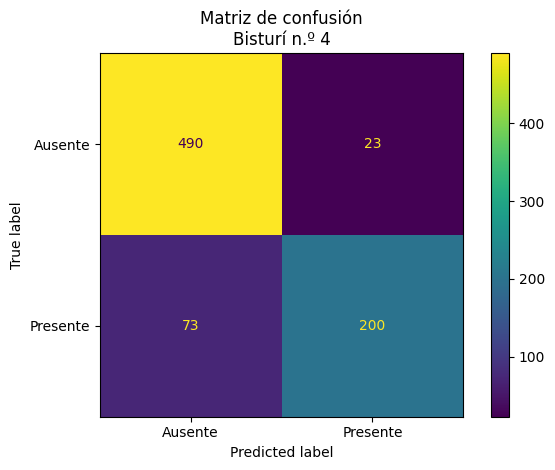

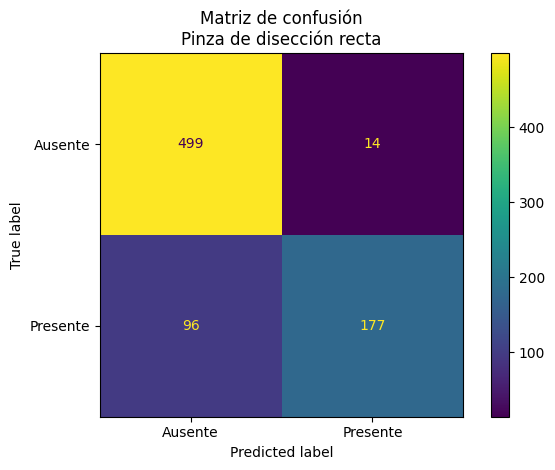

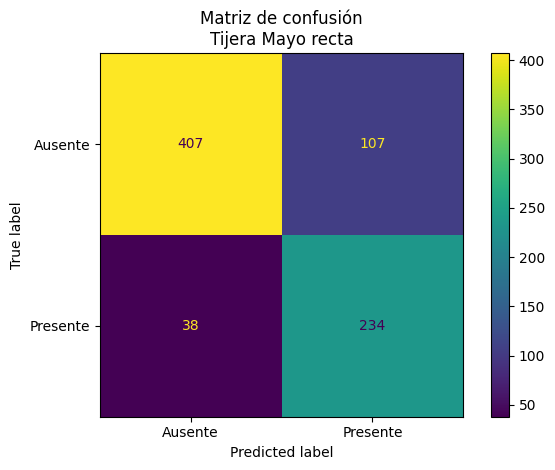

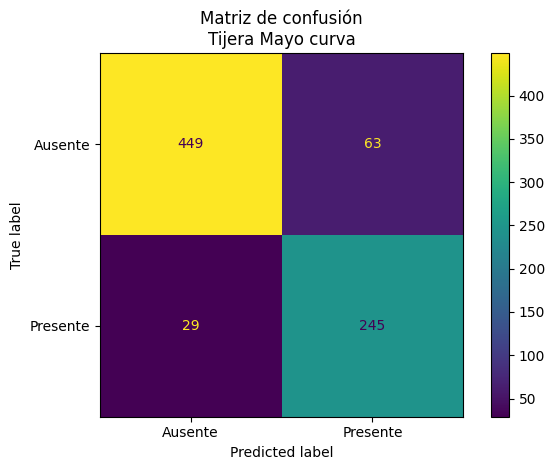

,Instrumento,Verdaderos negativos,Falsos positivos,Falsos negativos,Verdaderos positivos
0,Bisturí n.º 4,490,23,73,200
1,Pinza de disección recta,499,14,96,177
2,Tijera Mayo recta,407,107,38,234
3,Tijera Mayo curva,449,63,29,245



Matrices de confusión guardadas en: /content/modelos_instrumentos/matrices_confusion.csv


In [ ]:

import os
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Crear una matriz de confusión para cada instrumento

resultados_confusion = []

for indice, nombre_clase in enumerate(CLASS_NAMES):

    matriz = confusion_matrix(
        y_true[:, indice],
        y_pred[:, indice],
        labels=[0, 1]
    )

    tn, fp, fn, tp = matriz.ravel()

    resultados_confusion.append(
        {
            "Instrumento": nombre_clase,
            "Verdaderos negativos": tn,
            "Falsos positivos": fp,
            "Falsos negativos": fn,
            "Verdaderos positivos": tp
        }
    )

    display_matriz = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=[
            "Ausente",
            "Presente"
        ]
    )

    display_matriz.plot(
        values_format="d"
    )

    plt.title(
        f"Matriz de confusión\n{nombre_clase}"
    )

    plt.tight_layout()
    plt.show()

# Crear una tabla resumen

tabla_confusion = pd.DataFrame(
    resultados_confusion
)

display(tabla_confusion)

# Guardar los resultados

RUTA_MATRICES = os.path.join(
    CARPETA_MODELOS,
    "matrices_confusion.csv"
)

tabla_confusion.to_csv(
    RUTA_MATRICES,
    index=False
)

print(
    "\nMatrices de confusión guardadas en:",
    RUTA_MATRICES
)

### 3.4 Selección de umbrales óptimos

Los umbrales de decisión se calculan exclusivamente con el conjunto de validación. Esto permite adaptar la decisión binaria a cada instrumento sin utilizar el conjunto de prueba para ajustar parámetros.

> **Interpretación:** una probabilidad se considera positiva cuando supera el umbral específico de su clase.

In [ ]:
# Calcular umbrales óptimos con el conjunto de validación

import json
import numpy as np
import pandas as pd

from sklearn.metrics import f1_score

y_val_true = val_df[
    LABEL_COLUMNS
].astype(int).to_numpy()

y_val_prob = model.predict(
    val_ds,
    verbose=1
)

umbrales_optimos = []
resultados_umbrales = []

for indice, nombre_clase in enumerate(CLASS_NAMES):

    mejor_umbral = 0.50
    mejor_f1 = 0.0

    for umbral in np.arange(
        0.10,
        0.91,
        0.01
    ):

        prediccion_clase = (
            y_val_prob[:, indice] >= umbral
        ).astype(int)

        valor_f1 = f1_score(
            y_val_true[:, indice],
            prediccion_clase,
            zero_division=0
        )

        if valor_f1 > mejor_f1:
            mejor_f1 = valor_f1
            mejor_umbral = float(umbral)

    umbrales_optimos.append(
        mejor_umbral
    )

    resultados_umbrales.append(
        {
            "Instrumento": nombre_clase,
            "Umbral óptimo": mejor_umbral,
            "F1 en validación": mejor_f1
        }
    )

umbrales_optimos = np.array(
    umbrales_optimos,
    dtype=np.float32
)

tabla_umbrales = pd.DataFrame(
    resultados_umbrales
)

display(
    tabla_umbrales.style.format(
        {
            "Umbral óptimo": "{:.2f}",
            "F1 en validación": "{:.4f}"
        }
    )
)

RUTA_UMBRALES = os.path.join(
    CARPETA_MODELOS,
    "umbrales_optimos.json"
)

with open(
    RUTA_UMBRALES,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        {
            nombre: float(umbral)
            for nombre, umbral in zip(
                CLASS_NAMES,
                umbrales_optimos
            )
        },
        archivo,
        ensure_ascii=False,
        indent=4
    )

print(
    "\nUmbrales guardados en:",
    RUTA_UMBRALES
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step


,Instrumento,Umbral óptimo,F1 en validación
0,Bisturí n.º 4,0.36,0.8372
1,Pinza de disección recta,0.35,0.8700
2,Tijera Mayo recta,0.47,0.7948
3,Tijera Mayo curva,0.50,0.8341



Umbrales guardados en: /content/modelos_instrumentos/umbrales_optimos.json


---

## 4. Resumen del cuaderno

<div style="padding:18px 22px; border-left:5px solid #1FA187; background:#F2FAF8; border-radius:8px; margin:12px 0 18px 0;">
  <b>Resultado general</b><br>
  El cuaderno integra aprendizaje para reconocer instrumentos quirúrgicos: clasificación multilabel con MobileNetV2.
</div>

### Etapas completadas

- Preparación y verificación del conjunto de datos.
- Construcción de los conjuntos de entrenamiento, validación y prueba.
- Entrenamiento inicial y ajuste fino de MobileNetV2.
- Evaluación global y análisis de métricas por clase.
- Selección de umbrales específicos para cada instrumento.